# 14 - Multimodal Inventory

Until this point we have mostly treated the GTFS feed as one trip-adjacency graph. Here we want to split that graph by `route_type` and see how different the transport layers really are. A bus edge, rail edge, and cable-car edge all mean consecutive scheduled stops, but their network sizes, service intensity, and available alternative paths are very different.

We make one streaming pass through `stop_times.txt`, assign each trip to a mode, and count that mode's station calls and directed segments. From those counters we build one graph per mode and compare size, density, connected components, largest-component share, degree, articulation points, and bridges.

The question we are trying to answer is: **which mode supplies most of the country's connectivity, and which modes are structurally fragile because they are almost just lines?**

We use the cleaned route, trip, and stop tables from notebook 01. Notebook 02's node and edge tables are only used as a consistency check. Everything we create is stored in `outputs/nb/14_multimodal_inventory/`, including the per-mode edge and stop-call tables, the inventory and structure summaries, a station-mode table, JSON summaries, and three comparison figures. Saving the long counters here also gives us a reusable cache for any later mode analysis that wants to avoid another scan of the 816 MB file.

## 1. Set up the working environment

We locate the repository, switch the working directory to its root, and define the shared `DATA` and `OUT` paths. If we run in Colab without a local checkout, the helper clones the repository first. Package installation only happens for imports that are missing, so rerunning this setup does not redo unnecessary work.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Python 3.14.5 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
Repo root: /Users/seanfourman/Desktop/israel-transit-network-resilience


## 2. Load libraries and define the mode inventory

We import the scientific libraries plus `csv`, which lets us stream the large stop-times file. We create this notebook's table and figure folders, set a fixed random seed for plotting samples, and collect the runtime controls in one place. The full scan normally takes a few minutes; after that we cache `edges_by_mode.csv` and `stop_mode_calls.csv`, so a normal rerun can load the counts in seconds. `FORCE_RESTREAM` is the switch for deliberately rebuilding the cache.

We also define the six `route_type` labels used throughout the analysis. Codes 8 and 715 need careful names: code 8 is used here by shared-taxi operators even though GTFS calls it trolleybus, and 715 is demand-responsive bus service. We preserve every unexpected code as `other (<code>)` instead of dropping it.

In [2]:
# --- Libraries, stage folders and cost knobs ------------------------------
_ensure('pandas', 'numpy', 'networkx', 'matplotlib', 'seaborn')

import csv, json, time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)

# A handful of rows in stop_times.txt are very long; raise the csv field limit up front.
csv.field_size_limit(10_000_000)

# --- Stage output folders -------------------------------------------------
STAGE = OUT / '14_multimodal_inventory'
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Cost knobs (see the markdown above) ---------------------------------
FORCE_RESTREAM = False           # True -> always re-read the 816 MB feed (3-6 minutes)
PROGRESS_EVERY = 2_000_000       # progress print interval during the streaming pass
FIG_DPI = 150                    # figure resolution; drop to 90 for smaller files
MAP_ALPHA = 0.45                 # point transparency on the geographic mode map
MAP_MAX_POINTS_PER_MODE = 40_000 # subsample cap per mode on the map
SEED = 42                        # fixes the map subsample

# --- GTFS mode vocabulary (labels match notebook 11) ----------------------
MODE_LABELS = {
    '0': 'tram/light rail',
    '2': 'rail',
    '3': 'bus',
    '5': 'cable tram',
    '8': 'trolleybus/taxi-coded',
    '715': 'demand/other bus',
}
UNKNOWN_MODE = 'unknown'

def mode_label(route_type):
    """Human-readable name for a GTFS route_type code; never raises, never drops."""
    code = str(route_type).strip()
    if code == '' or code.lower() == 'nan':
        return UNKNOWN_MODE
    return MODE_LABELS.get(code, f'other ({code})')

print('stage folder :', STAGE)
print('modes tracked:', ', '.join(MODE_LABELS.values()))

stage folder : /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/14_multimodal_inventory
modes tracked: tram/light rail, rail, bus, cable tram, trolleybus/taxi-coded, demand/other bus


## 3. Make Hebrew station names readable

The figures use Hebrew station names, so we select a font with Hebrew glyphs. This Matplotlib version already draws the raw logical-order strings correctly, which means `fix_he` stays a no-op. We keep the raw names throughout the tables and plots and avoid applying a second bidi transformation.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We do not pre-reorder it with python-bidi because that would reverse it a second time.
# fix_he is a no-op here, and we only select a Hebrew-capable font. (If Hebrew renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## 4. Load the cleaned GTFS tables

We find the notebook 01 output folder by its `01` prefix and load `routes_clean.csv`, `trips_clean.csv`, and `stops_clean.csv`. The helper fails with a clear path if a required table is missing, because continuing with an empty mapping would quietly classify trips as unknown.

We force all GTFS identifiers and `route_type` values to strings. They are codes rather than measurements, and automatic numeric conversion can remove leading zeros or make joins fail. The cell prints the row counts and the set of mode codes so we can verify the inputs before building the trip-to-mode lookup.

In [4]:
# --- Resolve earlier stages by their two-digit prefix ---------------------
def find_stage(prefix, notebook_hint):
    """Return an earlier stage's output folder, matched by its NN prefix."""
    matches = sorted(p for p in OUT.glob(f'{prefix}*') if p.is_dir())
    if not matches:
        raise FileNotFoundError(
            f'No stage folder starting with "{prefix}" under {OUT}. '
            f'Run notebook {notebook_hint} first.')
    return matches[0]


def stage_artifact(prefix, filename, notebook_hint):
    """Path of `filename` inside stage `prefix`, or a FileNotFoundError that says why."""
    stage = find_stage(prefix, notebook_hint)
    direct = stage / 'tables' / filename
    if direct.exists():
        return direct
    hits = sorted(stage.rglob(filename))
    if not hits:
        raise FileNotFoundError(
            f'{filename} not found under {stage}. '
            f'Run notebook {notebook_hint} first - it writes {filename}.')
    return hits[0]


def read_gtfs_table(path):
    """GTFS ids are opaque codes: read every column as a string, keep blanks as ''."""
    return pd.read_csv(path, dtype=str, keep_default_na=False, encoding='utf-8-sig')


routes = read_gtfs_table(stage_artifact('01', 'routes_clean.csv', '01_data_preparation'))
trips = read_gtfs_table(stage_artifact('01', 'trips_clean.csv', '01_data_preparation'))
stops = read_gtfs_table(stage_artifact('01', 'stops_clean.csv', '01_data_preparation'))

for name, frame, column in [('routes_clean', routes, 'route_type'),
                            ('trips_clean', trips, 'route_id'),
                            ('stops_clean', stops, 'stop_id')]:
    if column not in frame.columns:
        raise KeyError(f'{name}.csv has no "{column}" column - re-run 01_data_preparation.')

print(f'routes: {len(routes):,}   trips: {len(trips):,}   stops: {len(stops):,}')
print('route_type codes present:', sorted(set(routes['route_type'])))

routes: 7,792   trips: 420,133   stops: 34,932
route_type codes present: ['0', '2', '3', '5', '715', '8']


## 5. Map every trip to a transport mode

`stop_times.txt` contains `trip_id` but not `route_type`, so we join in two steps: trip to route, then route to mode. We turn that result into a `trip_id -> mode_label` dictionary so the streaming loop needs only one lookup when a new trip block begins.

The same join gives the route and scheduled-trip counts by mode. We print trips whose route is missing from the route table; that value needs to be zero before we trust the split. On this feed the lookup covers all 420,133 trips, with bus accounting for 412,544 of them.

In [5]:
# --- route_id -> route_type -> mode label, then trip_id -> mode label -----
route_type_of = dict(zip(routes['route_id'], routes['route_type']))
trip_mode = {trip: mode_label(route_type_of.get(route, ''))
             for trip, route in zip(trips['trip_id'], trips['route_id'])}

orphan_trips = sum(1 for route in trips['route_id'] if route not in route_type_of)

# Route records and scheduled trips per mode, straight from the small GTFS tables.
trips_typed = trips.assign(route_type=trips['route_id'].map(route_type_of).fillna(''))
meta = pd.DataFrame({
    'routes': routes.groupby('route_type').size(),
    'trips': trips_typed.groupby('route_type').size(),
}).fillna(0).astype(int)
meta.index.name = 'route_type'
meta = meta.reset_index()
meta['mode_label'] = meta['route_type'].map(mode_label)
meta = meta.sort_values('trips', ascending=False).reset_index(drop=True)

print(f'trip_id -> mode entries: {len(trip_mode):,}')
print(f'trips whose route_id is missing from routes_clean.csv: {orphan_trips:,}')
meta

trip_id -> mode entries: 420,133
trips whose route_id is missing from routes_clean.csv: 0


,route_type,routes,trips,mode_label
0,3,6796,412544,bus
1,5,4,3006,cable tram
2,0,8,2890,tram/light rail
3,2,962,1188,rail
4,715,14,458,demand/other bus
5,8,8,47,trolleybus/taxi-coded


## 6. Make sure `stop_times.txt` is available

The station sequences live in `stop_times.txt`, which is about 816 MB and is not stored with the smaller project files. We download it from the configured Google Drive file only when it is missing and then print its size. This is the only network download in the notebook; all later processing reads the local file.

In [6]:
# stop_times.txt is 816MB and is not tracked in git - fetch it on demand.
_ensure("gdown")
import gdown
STOP_TIMES = DATA / "stop_times.txt"
if not STOP_TIMES.exists():
    gdown.download(id="1V_yPAWXV6mGTFGrfiosah5LngcLZnviW",
                   output=str(STOP_TIMES), quiet=False)
print("stop_times.txt:", round(STOP_TIMES.stat().st_size / 1024**2, 1), "MB")

stop_times.txt: 778.3 MB


## 7. Stream the file once and count each mode separately

This is the expensive cell. We read one row at a time and keep only compact counters rather than materializing 15.7 million rows. When two consecutive rows belong to the same trip, we increment the directed segment for that trip's mode. We also count scheduled calls by `(mode, stop)` and keep row and trip totals for checking coverage.

The loop assumes trip blocks and stop sequences are already ordered, which is the same ordering we checked when building the main graph. It skips and counts self-loops, assigns unmatched trips to `unknown`, and prints progress without changing the result. No clock fields are parsed because this notebook only needs adjacency.

If the two cached counter tables already exist and `FORCE_RESTREAM` is false, we reload them instead. The printed totals should still account for every row and show the expected station and segment counts for all six modes.

In [7]:
# --- One pass over stop_times.txt, routing every segment to its mode ------
EDGES_BY_MODE = TABLES / 'edges_by_mode.csv'
STOP_MODE_CALLS = TABLES / 'stop_mode_calls.csv'
STREAM_STATS = STAGE / 'stream_stats.json'


def stream_mode_edges(path, trip_mode, progress_every=PROGRESS_EVERY):
    """Build one segment-weight counter per transport mode in a single streaming pass.

    Assumes the feed is sorted by (trip_id, stop_sequence), verified in notebook 02.
    Memory is O(|E| + |V|), never O(rows).
    """
    edge_counts = defaultdict(Counter)   # mode -> Counter[(u, v)] = trips on that segment
    stop_calls = defaultdict(Counter)    # mode -> Counter[stop_id] = scheduled stop calls
    trips_observed = Counter()           # mode -> distinct trips met in the feed
    rows_by_mode = Counter()
    rows_read = 0
    self_loops = 0
    t0 = time.time()

    with open(path, encoding='utf-8-sig', newline='') as handle:
        reader = csv.reader(handle)
        header = next(reader)
        for field in ('trip_id', 'stop_id'):
            if field not in header:
                raise ValueError(f'stop_times.txt has no "{field}" column')
        i_trip, i_stop = header.index('trip_id'), header.index('stop_id')

        prev_trip, prev_stop, mode = None, None, UNKNOWN_MODE
        for row in reader:
            rows_read += 1
            trip, stop = row[i_trip], row[i_stop]

            if trip != prev_trip:
                # New trip block: resolve the mode once per trip, not once per row,
                # and reset the predecessor so no edge crosses a trip boundary.
                mode = trip_mode.get(trip, UNKNOWN_MODE)
                trips_observed[mode] += 1
                prev_stop = None

            rows_by_mode[mode] += 1
            stop_calls[mode][stop] += 1
            if prev_stop is not None:
                if prev_stop != stop:
                    edge_counts[mode][(prev_stop, stop)] += 1
                else:
                    self_loops += 1

            prev_trip, prev_stop = trip, stop
            if progress_every and rows_read % progress_every == 0:
                print(f'    {rows_read:,} rows | {time.time() - t0:,.0f}s')

    stats = {
        'rows_read': rows_read,
        'self_loop_rows_skipped': self_loops,
        'rows_by_mode': dict(rows_by_mode),
        'trips_observed': dict(trips_observed),
        'elapsed_seconds': round(time.time() - t0, 1),
    }
    return edge_counts, stop_calls, stats


cache_files = (EDGES_BY_MODE, STOP_MODE_CALLS, STREAM_STATS)
cache_inputs = (STOP_TIMES, DATA / 'routes.txt', DATA / 'trips.txt')
newest_input = max(p.stat().st_mtime_ns for p in cache_inputs)
cache_ready = (all(p.exists() for p in cache_files)
               and min(p.stat().st_mtime_ns for p in cache_files) >= newest_input)
loaded_from_cache = False
if cache_ready and not FORCE_RESTREAM:
    try:
        _cached_edges = pd.read_csv(EDGES_BY_MODE, dtype=str, keep_default_na=False,
                                    encoding='utf-8-sig')
        _cached_calls = pd.read_csv(STOP_MODE_CALLS, dtype=str, keep_default_na=False,
                                    encoding='utf-8-sig')
        required_edges = {'mode_label', 'from_stop', 'to_stop', 'trip_frequency'}
        required_calls = {'mode_label', 'stop_id', 'stop_calls'}
        if not required_edges.issubset(_cached_edges.columns):
            raise ValueError('edges_by_mode.csv has an invalid schema')
        if not required_calls.issubset(_cached_calls.columns):
            raise ValueError('stop_mode_calls.csv has an invalid schema')
        with open(STREAM_STATS, encoding='utf-8') as handle:
            stream_stats = json.load(handle)
        if int(stream_stats.get('rows_read', 0)) <= 0:
            raise ValueError('stream_stats.json has no positive rows_read value')

        edge_counts = defaultdict(Counter)
        for m, u, v, w in zip(_cached_edges['mode_label'], _cached_edges['from_stop'],
                              _cached_edges['to_stop'], _cached_edges['trip_frequency']):
            edge_counts[m][(u, v)] = int(w)
        stop_calls = defaultdict(Counter)
        for m, s, c in zip(_cached_calls['mode_label'], _cached_calls['stop_id'],
                           _cached_calls['stop_calls']):
            stop_calls[m][s] = int(c)
        if not edge_counts or not stop_calls:
            raise ValueError('cached mode counters are empty')
        loaded_from_cache = True
        print('Re-using the current, schema-checked per-mode cache.')
    except Exception as exc:
        print('Ignoring an invalid mode cache:', exc)

if not loaded_from_cache:
    reason = 'FORCE_RESTREAM=True' if FORCE_RESTREAM else 'cache missing, stale, or invalid'
    print('Streaming stop_times.txt (~15.7M rows) -', reason, '...')
    edge_counts, stop_calls, stream_stats = stream_mode_edges(STOP_TIMES, trip_mode)

print('rows read       : {:,}'.format(stream_stats['rows_read']))
print('self-loop rows  : {:,}'.format(stream_stats['self_loop_rows_skipped']))
print('elapsed seconds :', stream_stats['elapsed_seconds'])
print()
print('{:<24}{:>16}{:>10}{:>9}{:>11}'.format('mode', 'stop-time rows', 'trips',
                                             'stops', 'segments'))
for m, n_rows in sorted(stream_stats['rows_by_mode'].items(), key=lambda kv: -kv[1]):
    print('{:<24}{:>16,}{:>10,}{:>9,}{:>11,}'.format(
        m, n_rows, stream_stats['trips_observed'].get(m, 0),
        len(stop_calls.get(m, {})), len(edge_counts.get(m, {}))))

Streaming stop_times.txt (~15.7M rows) - cache missing, stale, or invalid ...
    2,000,000 rows | 1s
    4,000,000 rows | 3s
    6,000,000 rows | 4s
    8,000,000 rows | 6s
    10,000,000 rows | 7s
    12,000,000 rows | 9s
    14,000,000 rows | 10s
rows read       : 15,711,624
self-loop rows  : 718
elapsed seconds : 11.2

mode                      stop-time rows     trips    stops   segments
bus                           15,608,376   412,544   30,170     51,503
tram/light rail                   70,333     2,890      138        134
rail                              14,601     1,188       67        197
cable tram                        10,830     3,006        9         14
demand/other bus                   7,390       458      153        197
trolleybus/taxi-coded                 94        47       10          6


## 8. Save the streaming counters

We write the counters before doing any graph analysis. `edges_by_mode.csv` has one row per mode and directed station pair with its trip frequency. `stop_mode_calls.csv` has one row per mode and station with the number of scheduled calls. `stream_stats.json` keeps the row, trip, self-loop, and timing counters.

These files are both a cache for this notebook and reusable exports for later mode analysis. We write the CSVs as UTF-8 with a BOM so the Hebrew text remains readable when opened outside Python.

In [8]:
# --- Persist the streaming result (also serves as the cache) --------------
edges_by_mode = pd.DataFrame(
    [{'mode_label': m, 'from_stop': u, 'to_stop': v, 'trip_frequency': int(w)}
     for m, counter in edge_counts.items() for (u, v), w in counter.items()]
)
_edges_tmp = EDGES_BY_MODE.with_suffix('.csv.tmp')
edges_by_mode.to_csv(_edges_tmp, index=False, encoding='utf-8-sig')
_edges_tmp.replace(EDGES_BY_MODE)

stop_mode_calls = pd.DataFrame(
    [{'mode_label': m, 'stop_id': s, 'stop_calls': int(c)}
     for m, counter in stop_calls.items() for s, c in counter.items()]
)
_calls_tmp = STOP_MODE_CALLS.with_suffix('.csv.tmp')
stop_mode_calls.to_csv(_calls_tmp, index=False, encoding='utf-8-sig')
_calls_tmp.replace(STOP_MODE_CALLS)

_stats_tmp = STREAM_STATS.with_suffix('.json.tmp')
with open(_stats_tmp, 'w', encoding='utf-8') as handle:
    json.dump(stream_stats, handle, ensure_ascii=False, indent=2)
_stats_tmp.replace(STREAM_STATS)

print(f'{len(edges_by_mode):,} (mode, segment) rows -> {EDGES_BY_MODE}')
print(f'{len(stop_mode_calls):,} (mode, stop) rows    -> {STOP_MODE_CALLS}')
print(f'streaming counters                  -> {STREAM_STATS}')
edges_by_mode.head()

52,051 (mode, segment) rows -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/14_multimodal_inventory/tables/edges_by_mode.csv
30,547 (mode, stop) rows    -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/14_multimodal_inventory/tables/stop_mode_calls.csv
streaming counters                  -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/14_multimodal_inventory/stream_stats.json


,mode_label,from_stop,to_stop,trip_frequency
0,bus,38725,15582,112
1,bus,15582,15583,216
2,bus,15583,16086,152
3,bus,16086,16085,186
4,bus,16085,16084,152


## 9. Build and measure one graph per mode

For each observed mode we build a directed graph from its own segments and then an undirected projection that sums service in both directions. A node is a station served by that mode, an edge is a consecutive-stop relation, and the weight is scheduled trip frequency. We do not create a mode graph by taking an induced subgraph of the national graph, because that could include edges operated by another mode.

We calculate size, density, mean and median degree, connected components, largest-component share, articulation points, and bridges with the same definitions for every mode. We also store normalized articulation and bridge shares, which are more useful than raw counts when comparing a 30,000-node bus layer with a nine-node cable layer.

Modes with route records but no usable segment still receive a zero row. The cell prints the graph sizes and the complete structure table so we can spot a broken mode assignment immediately.

In [9]:
# --- Build and measure one network per mode ------------------------------
def build_mode_graphs(counter):
    """Directed trip-adjacency graph for one mode, plus its summed undirected view."""
    D = nx.DiGraph()
    for (u, v), w in counter.items():
        D.add_edge(u, v, weight=int(w))
    G = nx.Graph()
    for u, v, data in D.edges(data=True):
        if G.has_edge(u, v):
            G[u][v]['weight'] += data['weight']
        else:
            G.add_edge(u, v, weight=data['weight'])
    return G, D


def summarise_mode(label, G, D):
    """Size, sparsity, fragmentation and cut structure of a single mode's network."""
    n = G.number_of_nodes()
    m = G.number_of_edges()
    sizes = sorted((len(c) for c in nx.connected_components(G)), reverse=True)
    degrees = np.array([d for _, d in G.degree()]) if n else np.array([0])
    articulation = sorted(set(nx.articulation_points(G))) if n else []
    bridges = list(nx.bridges(G)) if n else []
    return {
        'mode_label': label,
        'nodes': n,
        'edges': m,
        'directed_edges': D.number_of_edges(),
        'components': len(sizes),
        'largest_component_nodes': sizes[0] if sizes else 0,
        'largest_component_share': round(sizes[0] / n, 4) if n else 0.0,
        'avg_degree': round(float(degrees.mean()), 2) if n else 0.0,
        'median_degree': float(np.median(degrees)) if n else 0.0,
        'max_degree': int(degrees.max()) if n else 0,
        'density': round(nx.density(G), 6) if n > 1 else 0.0,
        'articulation_points': len(articulation),
        'bridges': len(bridges),
        'articulation_share': round(len(articulation) / n, 4) if n else 0.0,
        'bridge_share': round(len(bridges) / m, 4) if m else 0.0,
    }


observed_modes = sorted(edge_counts, key=lambda m: -len(edge_counts[m]))
declared_only = [m for m in meta['mode_label'] if m not in observed_modes]

mode_graphs = {}
rows = []
for label in observed_modes + declared_only:
    t0 = time.time()
    G_mode, D_mode = build_mode_graphs(edge_counts.get(label, Counter()))
    mode_graphs[label] = (G_mode, D_mode)
    rows.append(summarise_mode(label, G_mode, D_mode))
    print('{:<24}{:>8,} nodes{:>9,} edges   ({:.1f}s)'.format(
        label, G_mode.number_of_nodes(), G_mode.number_of_edges(), time.time() - t0))

structure = pd.DataFrame(rows).sort_values('nodes', ascending=False).reset_index(drop=True)
structure

bus                       30,169 nodes   51,387 edges   (0.4s)
rail                          67 nodes       99 edges   (0.0s)
demand/other bus             153 nodes      194 edges   (0.0s)
tram/light rail              138 nodes      134 edges   (0.0s)
cable tram                     9 nodes        7 edges   (0.0s)
trolleybus/taxi-coded          8 nodes        5 edges   (0.0s)


,mode_label,nodes,edges,directed_edges,components,largest_component_nodes,largest_component_share,avg_degree,median_degree,max_degree,density,articulation_points,bridges,articulation_share,bridge_share
0,bus,30169,51387,51503,2,30165,0.9999,3.41,3.0,62,0.000113,754,812,0.0250,0.0158
1,demand/other bus,153,194,197,2,129,0.8431,2.54,2.0,6,0.016684,21,12,0.1373,0.0619
2,tram/light rail,138,134,134,4,35,0.2536,1.94,2.0,3,0.014175,128,134,0.9275,1.0000
3,rail,67,99,197,1,67,1.0000,2.96,2.0,8,0.044776,14,11,0.2090,0.1111
4,cable tram,9,7,14,2,6,0.6667,1.56,2.0,2,0.194444,5,7,0.5556,1.0000
5,trolleybus/taxi-coded,8,5,6,3,4,0.5000,1.25,1.0,3,0.178571,1,5,0.1250,1.0000


## 10. Write the service inventory

We combine the metadata counts with the observed network counts in `mode_inventory.csv`. `routes` and `trips` describe how much scheduled service is defined, while `stops` and `directed_edges` describe the footprint found in the stop sequences.

The distinction matters. In this run, heavy rail has 962 route records but only 1,188 trips, while light rail has 8 route records and 2,890 trips over 138 stop IDs. A GTFS route record is often one directional service variant, so we do not interpret it as a physical line.

In [10]:
# --- tables/mode_inventory.csv -------------------------------------------
observed_stops = {m: len(c) for m, c in stop_calls.items()}
observed_edges = {m: len(c) for m, c in edge_counts.items()}

inventory = meta.copy()
inventory['stops'] = inventory['mode_label'].map(observed_stops).fillna(0).astype(int)
inventory['directed_edges'] = (inventory['mode_label'].map(observed_edges)
                               .fillna(0).astype(int))

# Modes seen while streaming but absent from routes_clean.csv are added, not dropped.
extra_modes = [m for m in observed_stops if m not in set(inventory['mode_label'])]
if extra_modes:
    print('Modes present in stop_times.txt but not in routes_clean.csv:', extra_modes)
    inventory = pd.concat([inventory, pd.DataFrame([
        {'route_type': '', 'mode_label': m, 'routes': 0, 'trips': 0,
         'stops': observed_stops[m], 'directed_edges': observed_edges.get(m, 0)}
        for m in extra_modes])], ignore_index=True)

mode_inventory = (inventory[['route_type', 'mode_label', 'routes', 'trips',
                             'stops', 'directed_edges']]
                  .sort_values('trips', ascending=False)
                  .reset_index(drop=True))
mode_inventory.to_csv(TABLES / 'mode_inventory.csv', index=False, encoding='utf-8-sig')

print('saved:', TABLES / 'mode_inventory.csv')
mode_inventory

saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/14_multimodal_inventory/tables/mode_inventory.csv


,route_type,mode_label,routes,trips,stops,directed_edges
0,3,bus,6796,412544,30170,51503
1,5,cable tram,4,3006,9,14
2,0,tram/light rail,8,2890,138,134
3,2,rail,962,1188,67,197
4,715,demand/other bus,14,458,153,197
5,8,trolleybus/taxi-coded,8,47,10,6


## 11. Write the structural comparison tables

We save the compact columns needed by later notebooks to `mode_network_summary.csv`: mode, nodes, edges, components, largest-component share, average degree, articulation points, and bridges. We put density, detailed degree statistics, directed-edge count, normalized cut shares, routes, trips, and service ratios in `mode_structure_details.csv`.

The JSON copy holds the same values in a nested structure for quick programmatic use. Keeping one compact table and one detailed table lets us reuse a stable schema without throwing away the extra measurements used in this notebook.

In [11]:
# --- tables/mode_network_summary.csv (exact required schema) -------------
mode_network_summary = structure[[
    'mode_label', 'nodes', 'edges', 'components', 'largest_component_share',
    'avg_degree', 'articulation_points', 'bridges']].copy()
mode_network_summary.to_csv(TABLES / 'mode_network_summary.csv',
                            index=False, encoding='utf-8-sig')

# --- tables/mode_structure_details.csv (remaining measures) ---------------
details = structure.merge(
    mode_inventory[['mode_label', 'route_type', 'routes', 'trips']],
    on='mode_label', how='left')
details['routes'] = details['routes'].fillna(0).astype(int)
details['trips'] = details['trips'].fillna(0).astype(int)
details['route_type'] = details['route_type'].fillna('')
details['observed_trips'] = (details['mode_label']
                             .map(stream_stats['trips_observed']).fillna(0).astype(int))
details['stop_time_rows'] = (details['mode_label']
                             .map(stream_stats['rows_by_mode']).fillna(0).astype(int))
details['trips_per_edge'] = np.where(
    details['edges'] > 0,
    (details['observed_trips'] / details['edges'].replace(0, np.nan)).round(2), 0.0)
details = details[[
    'route_type', 'mode_label', 'routes', 'trips', 'observed_trips', 'stop_time_rows',
    'nodes', 'edges', 'directed_edges', 'density', 'avg_degree', 'median_degree',
    'max_degree', 'components', 'largest_component_nodes', 'largest_component_share',
    'articulation_points', 'articulation_share', 'bridges', 'bridge_share',
    'trips_per_edge']]
details.to_csv(TABLES / 'mode_structure_details.csv', index=False, encoding='utf-8-sig')

# --- mode_comparison_summary.json ---------------------------------------
comparison_summary = {
    'modes': int(len(structure)),
    'total_stop_time_rows': int(stream_stats['rows_read']),
    'total_directed_segments_all_modes': int(structure['directed_edges'].sum()),
    'per_mode': {row['mode_label']: {key: row[key] for key in (
        'nodes', 'edges', 'directed_edges', 'components', 'largest_component_share',
        'avg_degree', 'density', 'articulation_points', 'articulation_share',
        'bridges', 'bridge_share')} for _, row in structure.iterrows()},
}
with open(STAGE / 'mode_comparison_summary.json', 'w', encoding='utf-8') as handle:
    json.dump(comparison_summary, handle, ensure_ascii=False, indent=2, default=float)

print('saved:', TABLES / 'mode_network_summary.csv')
print('saved:', TABLES / 'mode_structure_details.csv')
print('saved:', STAGE / 'mode_comparison_summary.json')
details

saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/14_multimodal_inventory/tables/mode_network_summary.csv
saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/14_multimodal_inventory/tables/mode_structure_details.csv
saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/14_multimodal_inventory/mode_comparison_summary.json


,route_type,mode_label,routes,trips,observed_trips,stop_time_rows,nodes,edges,directed_edges,density,...,median_degree,max_degree,components,largest_component_nodes,largest_component_share,articulation_points,articulation_share,bridges,bridge_share,trips_per_edge
0,3,bus,6796,412544,412544,15608376,30169,51387,51503,0.000113,...,3.0,62,2,30165,0.9999,754,0.0250,812,0.0158,8.03
1,715,demand/other bus,14,458,458,7390,153,194,197,0.016684,...,2.0,6,2,129,0.8431,21,0.1373,12,0.0619,2.36
2,0,tram/light rail,8,2890,2890,70333,138,134,134,0.014175,...,2.0,3,4,35,0.2536,128,0.9275,134,1.0000,21.57
3,2,rail,962,1188,1188,14601,67,99,197,0.044776,...,2.0,8,1,67,1.0000,14,0.2090,11,0.1111,12.00
4,5,cable tram,4,3006,3006,10830,9,7,14,0.194444,...,2.0,2,2,6,0.6667,5,0.5556,7,1.0000,429.43
5,8,trolleybus/taxi-coded,8,47,47,94,8,5,6,0.178571,...,1.0,3,3,4,0.5000,1,0.1250,5,1.0000,9.40


## 12. Check that the mode split reconstructs the full graph

We take the union of every per-mode station set and segment set and compare it with notebook 02's all-mode tables when those files are available. The directed segment union should match exactly because both are built from the same consecutive-stop rule. The sum across modes can be larger than the union because one station or segment may be served by more than one mode.

On this run the union contains 51,999 directed segments, exactly the notebook 02 count. There are 81 extra `(mode, stop)` memberships beyond the unique-stop union, which is the raw overlap examined in notebook 17. The three-stop difference between the union and `nodes.csv` comes from served stops that never form a segment, not from a missing mode.

In [12]:
# --- Reconcile the per-mode split against the whole-network graph --------
union_stops = set().union(*(set(c) for c in stop_calls.values())) if stop_calls else set()
union_edges = set().union(*(set(c) for c in edge_counts.values())) if edge_counts else set()
sum_stops = sum(len(c) for c in stop_calls.values())
sum_edges = sum(len(c) for c in edge_counts.values())

print(f'union of per-mode stops    : {len(union_stops):,}')
print(f'sum  of per-mode stops     : {sum_stops:,}   (a stop counted once per mode)')
print(f'union of per-mode segments : {len(union_edges):,}')
print(f'sum  of per-mode segments  : {sum_edges:,}')
print(f'multimodal surplus (stops) : {sum_stops - len(union_stops):,} extra (mode, stop) pairs')

try:
    nodes_all = pd.read_csv(stage_artifact('02', 'nodes.csv', '02_graph_construction'),
                            dtype=str, keep_default_na=False, encoding='utf-8-sig')
    edges_all = pd.read_csv(stage_artifact('02', 'edges.csv', '02_graph_construction'),
                            dtype=str, keep_default_na=False, encoding='utf-8-sig')
    print()
    print(f'stage 02 nodes.csv rows    : {len(nodes_all):,}')
    print(f'stage 02 edges.csv rows    : {len(edges_all):,}  (directed)')
    print(f'segment difference         : {len(union_edges) - len(edges_all):+,}')
except FileNotFoundError as err:
    print()
    print('Skipping the stage-02 cross-check:', err)

union of per-mode stops    : 30,466
sum  of per-mode stops     : 30,547   (a stop counted once per mode)
union of per-mode segments : 51,999
sum  of per-mode segments  : 52,051
multimodal surplus (stops) : 81 extra (mode, stop) pairs

stage 02 nodes.csv rows    : 30,463
stage 02 edges.csv rows    : 51,999  (directed)
segment difference         : +0


## 13. Put the mode memberships on one row per station

We pivot the long stop-call table into a station-level table. Each row records the sorted `|`-separated mode list, number of modes, total scheduled calls, and the station attributes from `stops_clean.csv`. We keep rows even when a cleaned attribute is missing and print those counts rather than silently dropping them.

The resulting `stop_modes.csv` is the direct answer to “which modes touch this stop ID?” and is also a convenient input for the transfer analysis. On this feed 30,466 stops appear in the streamed calls and 81 are served by more than one mode.

In [13]:
# --- One row per stop: which modes serve it ------------------------------
geo = stops[['stop_id', 'stop_name', 'stop_lat', 'stop_lon']].copy()
geo['lat'] = pd.to_numeric(geo['stop_lat'], errors='coerce')
geo['lon'] = pd.to_numeric(geo['stop_lon'], errors='coerce')
for column in ('region', 'metro'):
    geo[column] = stops[column] if column in stops.columns else ''
geo = geo[['stop_id', 'stop_name', 'lat', 'lon', 'region', 'metro']]

stop_mode_geo = stop_mode_calls.merge(geo, on='stop_id', how='left')
missing_attrs = int(stop_mode_geo['stop_name'].isna().sum())
missing_coords = int(stop_mode_geo['lat'].isna().sum())

stop_modes = (stop_mode_geo
              .groupby('stop_id', as_index=False)
              .agg(stop_name=('stop_name', 'first'),
                   lat=('lat', 'first'),
                   lon=('lon', 'first'),
                   region=('region', 'first'),
                   metro=('metro', 'first'),
                   n_modes=('mode_label', 'nunique'),
                   modes_served=('mode_label', lambda s: '|'.join(sorted(set(s)))),
                   stop_calls=('stop_calls', 'sum')))
stop_modes = stop_modes.sort_values(['n_modes', 'stop_calls'], ascending=False)
stop_modes.to_csv(TABLES / 'stop_modes.csv', index=False, encoding='utf-8-sig')

print(f'stops in the feed                  : {len(stop_modes):,}')
print(f'  serving more than one mode       : {int((stop_modes["n_modes"] > 1).sum()):,}')
print(f'  (mode, stop) rows with no name   : {missing_attrs:,}')
print(f'  (mode, stop) rows with no coords : {missing_coords:,}')
print('saved:', TABLES / 'stop_modes.csv')
stop_modes.head(10)

stops in the feed                  : 30,466
  serving more than one mode       : 81
  (mode, stop) rows with no name   : 0
  (mode, stop) rows with no coords : 0
saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/14_multimodal_inventory/tables/stop_modes.csv


,stop_id,stop_name,lat,lon,region,metro,n_modes,modes_served,stop_calls
826,11080,מחלף הרטוב,31.767298,34.997537,Jerusalem,Periphery,2,bus|demand/other bus,2066
827,11081,מחלף הרטוב,31.767124,34.997730,Jerusalem,Periphery,2,bus|demand/other bus,1982
780,11028,שדרות יגאל אלון/קניון שער העיר,31.756197,34.985749,Jerusalem,Periphery,2,bus|demand/other bus,1403
17035,37273,שדרות יגאל אלון/הצבע,31.753943,34.994399,Jerusalem,Periphery,2,bus|demand/other bus,1275
20293,41660,כביש 38/דולמיט,31.760419,34.987449,Jerusalem,Periphery,2,bus|demand/other bus,1241
786,11035,יגאל אלון/העלייה,31.755910,34.989729,Jerusalem,Periphery,2,bus|demand/other bus,1198
17036,37274,שדרות יגאל אלון/הצבע,31.753714,34.994922,Jerusalem,Periphery,2,bus|demand/other bus,1146
1010,11288,שד.יגאל אלון/הבנאי,31.754837,34.992821,Jerusalem,Periphery,2,bus|demand/other bus,1010
863,11119,מחלף מסילת ציון,31.798378,35.014456,Jerusalem,Jerusalem,2,bus|demand/other bus,968
16760,36797,כביש 3855/שדרות יגאל אלון,31.751453,35.000784,Jerusalem,Periphery,2,bus|demand/other bus,956


## 14. Compare mode size and service volume

We plot stations, undirected edges, and scheduled trips side by side for every mode. The y-axis is logarithmic because bus is several orders of magnitude larger than some of the other layers; a linear scale would make those smaller modes unreadable.

The point of this figure is to separate network footprint from service intensity. Bus dominates both size and total trips, while light rail and cable tram concentrate thousands of trips on very small graphs. We use the table for exact values and the plot to see these scale differences at once.

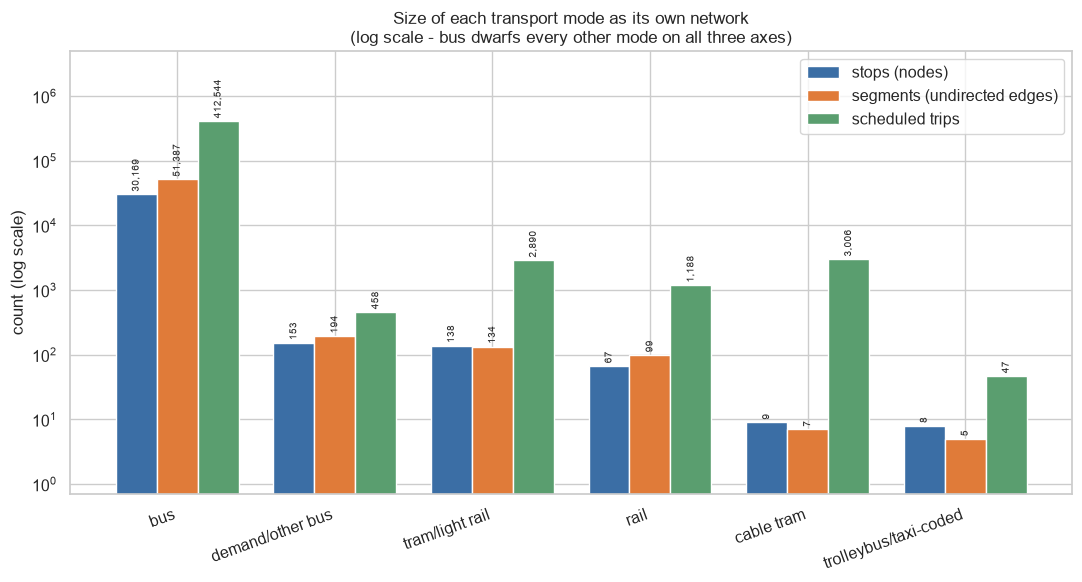

saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/14_multimodal_inventory/figures/mode_size_comparison.png


In [14]:
# --- Figure 1: grouped bar chart of size metrics per mode ----------------
plot_df = (mode_network_summary
           .merge(mode_inventory[['mode_label', 'trips']], on='mode_label', how='left')
           .fillna({'trips': 0})
           .sort_values('nodes', ascending=False)
           .reset_index(drop=True))

metrics = [('stops (nodes)', 'nodes'),
           ('segments (undirected edges)', 'edges'),
           ('scheduled trips', 'trips')]
x = np.arange(len(plot_df))
width = 0.26
colors = ['#3b6ea5', '#e07b39', '#5a9e6f']
ceiling = float(plot_df[['nodes', 'edges', 'trips']].to_numpy().max())

fig, ax = plt.subplots(figsize=(11, 6))
for k, (label, column) in enumerate(metrics):
    values = [max(int(v), 0) for v in plot_df[column]]
    bars = ax.bar(x + (k - 1) * width, values, width, label=label, color=colors[k])
    ax.bar_label(bars, labels=[f'{v:,}' for v in values],
                 fontsize=7, padding=2, rotation=90)

ax.set_yscale('log')
ax.set_ylim(0.7, ceiling * 12 if ceiling > 0 else 10)
ax.set_xticks(x)
ax.set_xticklabels(plot_df['mode_label'], rotation=20, ha='right')
ax.set_ylabel('count (log scale)')
ax.set_title('Size of each transport mode as its own network\n'
             '(log scale - bus dwarfs every other mode on all three axes)')
ax.legend(loc='upper right', frameon=True)
fig.tight_layout()
fig.savefig(FIGURES / 'mode_size_comparison.png', dpi=FIG_DPI)
plt.show()

print('saved:', FIGURES / 'mode_size_comparison.png')

## 15. Compare structural fragility

We use normalized measures in this figure so small and large modes can be compared. The three panels show average degree, the share of nodes that are articulation points, and the share of nodes in the largest component.

We need to read these together. A mode split into tiny shuttles can have few articulation points simply because there is almost nothing to split, while a connected path has nearly every internal node as a cut point. In this run light rail has average degree 1.94, 92.75% articulation points, and every edge is a bridge; bus has average degree 3.41 and only 2.5% articulation points.

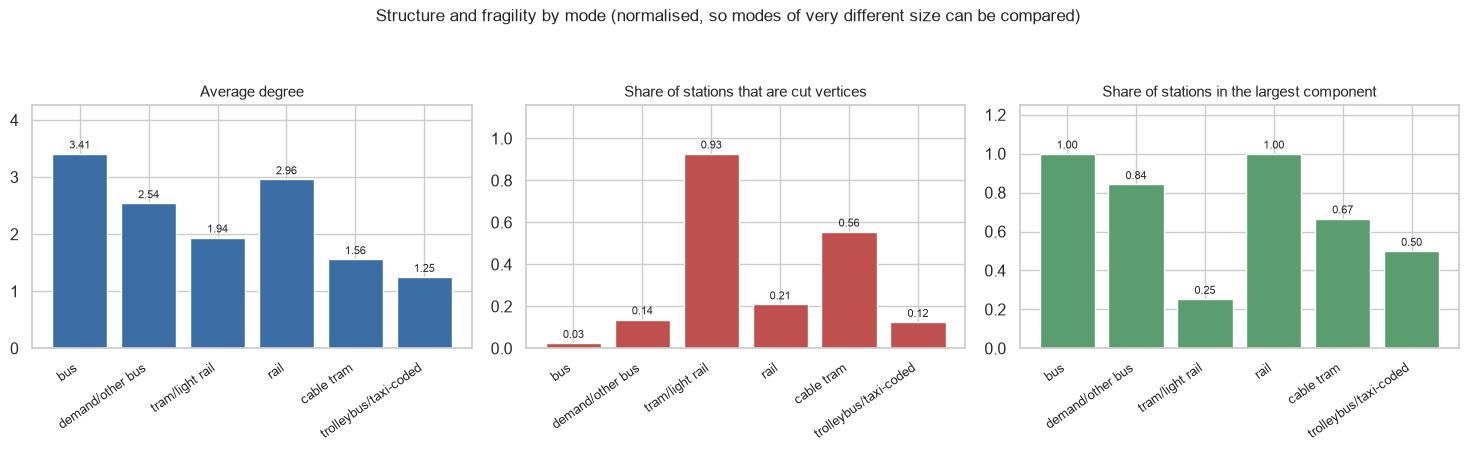

saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/14_multimodal_inventory/figures/mode_structure_comparison.png


In [15]:
# --- Figure 2: normalised structure / fragility per mode -----------------
frag = details.sort_values('nodes', ascending=False).reset_index(drop=True)
panels = [('avg_degree', 'Average degree', '#3b6ea5'),
          ('articulation_share', 'Share of stations that are cut vertices', '#c0504d'),
          ('largest_component_share', 'Share of stations in the largest component',
           '#5a9e6f')]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (column, title, color) in zip(axes, panels):
    values = [float(v) for v in frag[column]]
    bars = ax.bar(range(len(frag)), values, color=color)
    ax.bar_label(bars, labels=[f'{v:.2f}' for v in values], fontsize=8, padding=2)
    ax.set_xticks(range(len(frag)))
    ax.set_xticklabels(frag['mode_label'], rotation=35, ha='right', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, max(values) * 1.25 if max(values) > 0 else 1)

fig.suptitle('Structure and fragility by mode '
             '(normalised, so modes of very different size can be compared)',
             fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(FIGURES / 'mode_structure_comparison.png', dpi=FIG_DPI)
plt.show()

print('saved:', FIGURES / 'mode_structure_comparison.png')

## 16. Map where each mode operates

We plot station coordinates by mode, drawing large modes first and using larger markers for the small layers so they remain visible above the bus points. A station served by several modes appears once in each corresponding color. We correct the aspect ratio for latitude and use fixed-seed subsampling only if a mode exceeds `MAP_MAX_POINTS_PER_MODE`.

This map gives geographic meaning to the inventory: bus covers almost the whole country, rail follows a national corridor, and the smaller fixed-guideway modes occupy compact metropolitan systems. Any station without finite coordinates is counted and excluded from the picture.

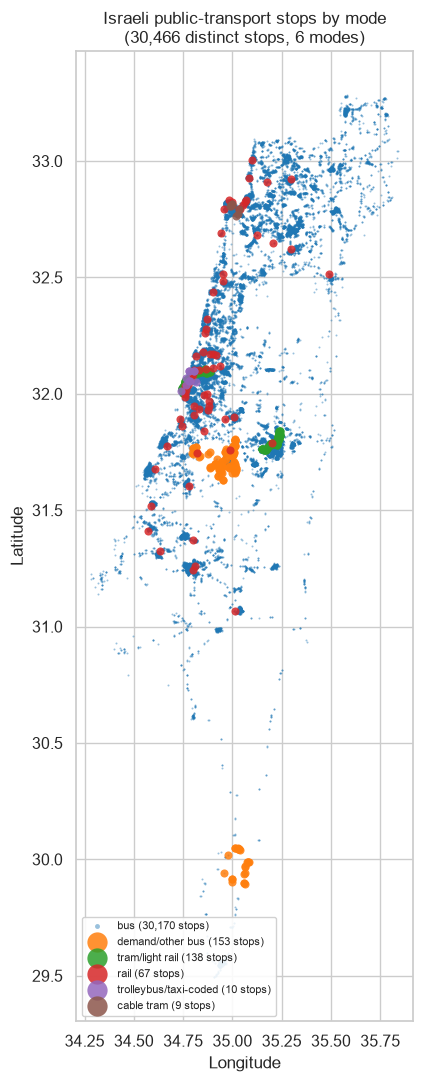

(mode, stop) rows without coordinates, excluded: 0
saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/14_multimodal_inventory/figures/mode_map.png


In [16]:
# --- Figure 3: stops coloured by mode ------------------------------------
map_df = stop_mode_geo.dropna(subset=['lat', 'lon']).copy()
dropped = len(stop_mode_geo) - len(map_df)
if map_df.empty:
    raise ValueError('No stop carries usable coordinates - check stops_clean.csv '
                     'from notebook 01_data_preparation.')

order = map_df.groupby('mode_label').size().sort_values(ascending=False).index.tolist()
palette = dict(zip(order, sns.color_palette('tab10', max(len(order), 3))))
rng = np.random.default_rng(SEED)

fig, ax = plt.subplots(figsize=(8, 11))
subsampled = []
for depth, mode in enumerate(order):
    sub = map_df[map_df['mode_label'] == mode]
    total = len(sub)
    if total > MAP_MAX_POINTS_PER_MODE:
        keep = rng.choice(total, MAP_MAX_POINTS_PER_MODE, replace=False)
        sub = sub.iloc[np.sort(keep)]
        subsampled.append(mode)
    size = 2 if total > 5_000 else (12 if total > 500 else 34)
    alpha = MAP_ALPHA if total > 5_000 else 0.85
    ax.scatter(sub['lon'], sub['lat'], s=size, alpha=alpha, linewidths=0,
               color=palette[mode], zorder=depth + 1,
               label=f'{mode} ({total:,} stops)')

ax.set_aspect(1 / np.cos(np.deg2rad(float(map_df['lat'].mean()))))
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Israeli public-transport stops by mode\n'
             '({:,} distinct stops, {} modes)'.format(map_df['stop_id'].nunique(),
                                                      len(order)))
ax.legend(loc='lower left', fontsize=8, markerscale=2.5, framealpha=0.9)
fig.tight_layout()
fig.savefig(FIGURES / 'mode_map.png', dpi=FIG_DPI)
plt.show()

print(f'(mode, stop) rows without coordinates, excluded: {dropped:,}')
if subsampled:
    print('subsampled for drawing only:', ', '.join(subsampled))
print('saved:', FIGURES / 'mode_map.png')

## 17. Interpreting why the layers look different

We want to connect the graph measurements with what each layer represents.

- **Bus (`route_type = 3`)** has 30,169 graph nodes and 51,387 undirected edges. Roads allow many overlapping services, so the metropolitan core is meshed, but long rural branches still create 754 articulation points and 812 bridges. Its failures are numerous but often local.
- **Rail (`route_type = 2`)** has 67 stations and 99 edges in one component. It is corridor-shaped, but express-stop adjacency creates extra graph edges, so it is not a literal track map. Fourteen stations are articulation points in this service graph.
- **Tram/light rail (`route_type = 0`)** has 138 stop IDs, 134 edges, and four components. Directional platforms are separate IDs, so the two physical systems appear doubled. All 134 edges are bridges and 128 stations are cut points.
- **Cable tram (`route_type = 5`)** is two short Haifa paths: nine nodes, seven edges, and no cycles.
- **Taxi-coded `route_type = 8`** is only eight graph nodes and five edges. We treat it as a shared-taxi coding category, not evidence of a trolleybus network.
- **Demand/other bus (`route_type = 715`)** has 153 nodes and 194 edges in two components. Its apparent meshing can reflect flexible route variants rather than built redundancy.

The overall pattern is that bus is the only large layer with substantial alternative routing. The dedicated-infrastructure layers concentrate service on small, mostly linear graphs. We also have to remember that these are timetable-adjacency edges and scheduled trips, not physical tracks or passengers.

## Conclusion

The mode split confirms that the merged national graph is numerically dominated by bus. Bus contributes 412,544 of 420,133 scheduled trips, 30,169 graph nodes, and 51,387 of the 51,772 undirected edges in the full graph. For most national-scale topology measures, we are therefore mostly measuring the bus system.

The smaller layers are not just scaled-down bus graphs. Light rail has 138 stop IDs and 134 edges split across four components; 128 nodes are articulation points and all 134 edges are bridges. Cable tram is two short paths with every edge a bridge. Bus, in contrast, has average degree 3.41, a 2.5% articulation share, and a 1.58% bridge share. This is a real difference between a meshed road-service layer and fixed corridor services.

Service volume gives a different ordering from network size. Light rail schedules 2,890 trips and cable tram 3,006 despite their tiny station sets, while heavy rail schedules 1,188 trips. We should therefore keep footprint, frequency, and structural redundancy as separate ideas rather than use one “largest mode” ranking for all of them.

The consistency checks also passed: the union of per-mode directed segments is exactly 51,999, matching the all-mode edge table, and no trip was left without a route-to-mode match. The 81 surplus mode memberships identify stops shared by more than one GTFS mode.

Two caveats matter for anything we do next. The route-type labels are not always physical modes—code 8 is shared taxi and 715 is demand-responsive bus—and service-adjacency edges are not infrastructure edges. Express trips can create shortcut edges, and trip counts measure scheduled supply rather than demand. With those limits in mind, we can use notebook 15 for the large bus layer, notebook 16 for the small corridor layers, and notebook 17 for the places where their station sets come close enough to transfer.